# Peramalan Permintaan dengan GRU (Daily, Weekly, Monthly)

Notebook ini membangun dan membandingkan model peramalan GRU (Gated Recurrent Unit) menggunakan tiga tingkat granularitas waktu: harian, mingguan, dan bulanan.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## Persiapan Data (Data Preparation)

In [2]:
# Load data
df = pd.read_csv('data/processed/cold_chain_data.csv')

# Convert to datetime and sort
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df = df.sort_values('order date (DateOrders)')

# Set index for resampling
df.set_index('order date (DateOrders)', inplace=True)

# Aggregation targets
target_col = 'Order Item Quantity'

# A. Daily Demand
df_daily = df[target_col].resample('D').sum().reset_index()

# B. Weekly Demand
df_weekly = df[target_col].resample('W').sum().reset_index()

# C. Monthly Demand
df_monthly = df[target_col].resample('M').sum().reset_index()

granularities = {
    'Daily': df_daily,
    'Weekly': df_weekly,
    'Monthly': df_monthly
}

print("=== Ringkasan Agregasi Permintaan ===\n")
for name, data in granularities.items():
    print(f"[{name} Demand]")
    print(f"- Jumlah observasi: {len(data)}")
    print(f"- Tanggal mulai: {data['order date (DateOrders)'].min().date()}")
    print(f"- Tanggal akhir: {data['order date (DateOrders)'].max().date()}")
    print(f"- Rata-rata permintaan: {data[target_col].mean():.2f}")
    print(f"- Standar deviasi: {data[target_col].std():.2f}\n")

=== Ringkasan Agregasi Permintaan ===

[Daily Demand]
- Jumlah observasi: 1127
- Tanggal mulai: 2015-01-01
- Tanggal akhir: 2018-01-31
- Rata-rata permintaan: 340.80
- Standar deviasi: 101.54

[Weekly Demand]
- Jumlah observasi: 162
- Tanggal mulai: 2015-01-04
- Tanggal akhir: 2018-02-04
- Rata-rata permintaan: 2370.86
- Standar deviasi: 688.01

[Monthly Demand]
- Jumlah observasi: 37
- Tanggal mulai: 2015-01-31
- Tanggal akhir: 2018-01-31
- Rata-rata permintaan: 10380.51
- Standar deviasi: 2919.38



## Eksplorasi Urutan Waktu (Sequence Exploration)

In [3]:
sequence_configs = {
    'Daily': [7, 14, 30],
    'Weekly': [4, 8, 12],
    'Monthly': [3, 6, 12]
}

print("=== Eksplorasi Sequence Length ===\n")
for name, seq_lengths in sequence_configs.items():
    n_obs = len(granularities[name])
    print(f"[{name} Demand] Total observasi: {n_obs}")
    for seq in seq_lengths:
        # Number of samples = Total - sequence_length
        n_samples = max(0, n_obs - seq)
        print(f"  - Sequence length: {seq:2d} -> Training/Testing samples generated: {n_samples}")
    print()

=== Eksplorasi Sequence Length ===

[Daily Demand] Total observasi: 1127
  - Sequence length:  7 -> Training/Testing samples generated: 1120
  - Sequence length: 14 -> Training/Testing samples generated: 1113
  - Sequence length: 30 -> Training/Testing samples generated: 1097

[Weekly Demand] Total observasi: 162
  - Sequence length:  4 -> Training/Testing samples generated: 158
  - Sequence length:  8 -> Training/Testing samples generated: 154
  - Sequence length: 12 -> Training/Testing samples generated: 150

[Monthly Demand] Total observasi: 37
  - Sequence length:  3 -> Training/Testing samples generated: 34
  - Sequence length:  6 -> Training/Testing samples generated: 31
  - Sequence length: 12 -> Training/Testing samples generated: 25



## Train/Test Split & GRU Modeling

- Membagi data 80% Train, 20% Test secara berurutan.
- Menggunakan MinMaxScaler hanya pada data latih (train).
- Membangun dan melatih model GRU untuk setiap granularitas dan *sequence length*.

In [4]:
# GRU PyTorch Model Definition
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :]) # Take the last time step
        return out

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data)-seq_length):
        xs.append(data[i:(i+seq_length)])
        ys.append(data[i+seq_length])
    return np.array(xs), np.array(ys)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_and_evaluate_gru(df_agg, seq_lengths, name, epochs=50, batch_size=16):
    results = []
    best_rmse = float('inf')
    best_model_info = None
    best_predictions = None
    
    values = df_agg[target_col].values.reshape(-1, 1)
    
    # 80/20 Split
    train_size = int(len(values) * 0.8)
    train_data, test_data = values[:train_size], values[train_size:]
    
    # MinMaxScaler
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data) # ONLY transform test data
    
    # Ensure folder exists
    os.makedirs('data/predicted-1', exist_ok=True)
    
    all_metrics = []
    
    for seq in seq_lengths:
        # Create sequences
        X_train, y_train = create_sequences(train_scaled, seq)
        X_test, y_test = create_sequences(test_scaled, seq)
        
        if len(X_train) == 0 or len(X_test) == 0:
            print(f"Skipping {name} seq {seq} due to insufficient data.")
            continue
            
        # Convert to PyTorch Tensors
        X_train_t = torch.tensor(X_train, dtype=torch.float32)
        y_train_t = torch.tensor(y_train, dtype=torch.float32)
        X_test_t = torch.tensor(X_test, dtype=torch.float32)
        y_test_t = torch.tensor(y_test, dtype=torch.float32)
        
        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
        
        model = GRUModel().to(device)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
        
        # Training Loop
        train_losses = []
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            train_losses.append(epoch_loss/len(train_loader))
            
        # Evaluation
        model.eval()
        with torch.no_grad():
            preds_scaled = model(X_test_t.to(device)).cpu().numpy()
            
        # Inverse transform
        preds = scaler.inverse_transform(preds_scaled)
        actuals = scaler.inverse_transform(y_test_t.numpy())
        
        # Calculate Metrics
        mae = mean_absolute_error(actuals, preds)
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        mape = mean_absolute_percentage_error(actuals, preds)
        r2 = r2_score(actuals, preds)
        
        all_metrics.append({
            'Granularity': name,
            'Sequence_Length': seq,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape,
            'R2': r2
        })
        
        if rmse < best_rmse:
            best_rmse = rmse
            # Get actual dates for the test set predictions
            # The test set starts at train_size, but the first prediction is at train_size + seq
            test_dates = df_agg['order date (DateOrders)'].iloc[train_size + seq : train_size + seq + len(preds)].values
            
            best_model_info = {
                'Granularity': name,
                'Best_Sequence': seq,
                'MAE': mae,
                'RMSE': rmse,
                'MAPE': mape,
                'R2': r2,
                'Train_Losses': train_losses
            }
            best_predictions = pd.DataFrame({
                'Date': test_dates,
                'Actual': actuals.flatten(),
                'Predicted': preds.flatten()
            })
            
    # Save metrics and predictions for this granularity
    pd.DataFrame(all_metrics).to_csv(f'data/predicted-1/{name.lower()}_metrics.csv', index=False)
    best_predictions.to_csv(f'data/predicted-1/{name.lower()}_predictions.csv', index=False)
    
    return best_model_info, best_predictions, all_metrics

# Run experiments
results_summary = []
all_granular_metrics = []
predictions_dict = {}

print("Training models... (This may take a minute)\n")
for name, data in granularities.items():
    print(f"Training Model {name}...")
    best_info, best_preds, metrics = train_and_evaluate_gru(data, sequence_configs[name], name, epochs=30)
    results_summary.append(best_info)
    all_granular_metrics.extend(metrics)
    predictions_dict[name] = best_preds
    print(f"  -> Selesai. Best Sequence: {best_info['Best_Sequence']}, RMSE: {best_info['RMSE']:.2f}")

Training models... (This may take a minute)

Training Model Daily...
  -> Selesai. Best Sequence: 7, RMSE: 219.21
Training Model Weekly...
  -> Selesai. Best Sequence: 4, RMSE: 1385.53
Training Model Monthly...
Skipping Monthly seq 12 due to insufficient data.
  -> Selesai. Best Sequence: 3, RMSE: 8083.46


## Pemilihan Urutan Waktu Terbaik (Best Sequence Selection)

In [5]:
df_results = pd.DataFrame(results_summary)
display(df_results[['Granularity', 'Best_Sequence', 'MAE', 'RMSE', 'MAPE', 'R2']])

# Save best model summary
df_results.drop(columns=['Train_Losses']).to_csv('data/predicted-1/best_model_summary.csv', index=False)

,Granularity,Best_Sequence,MAE,RMSE,MAPE,R2
0,Daily,7,175.303818,219.210435,2.403137,-1.339187
1,Weekly,4,1139.824707,1385.527517,2.450915,-1.007324
2,Monthly,3,7411.850098,8083.462130,3.322184,-4.909918


## Visualisasi (Visualization)

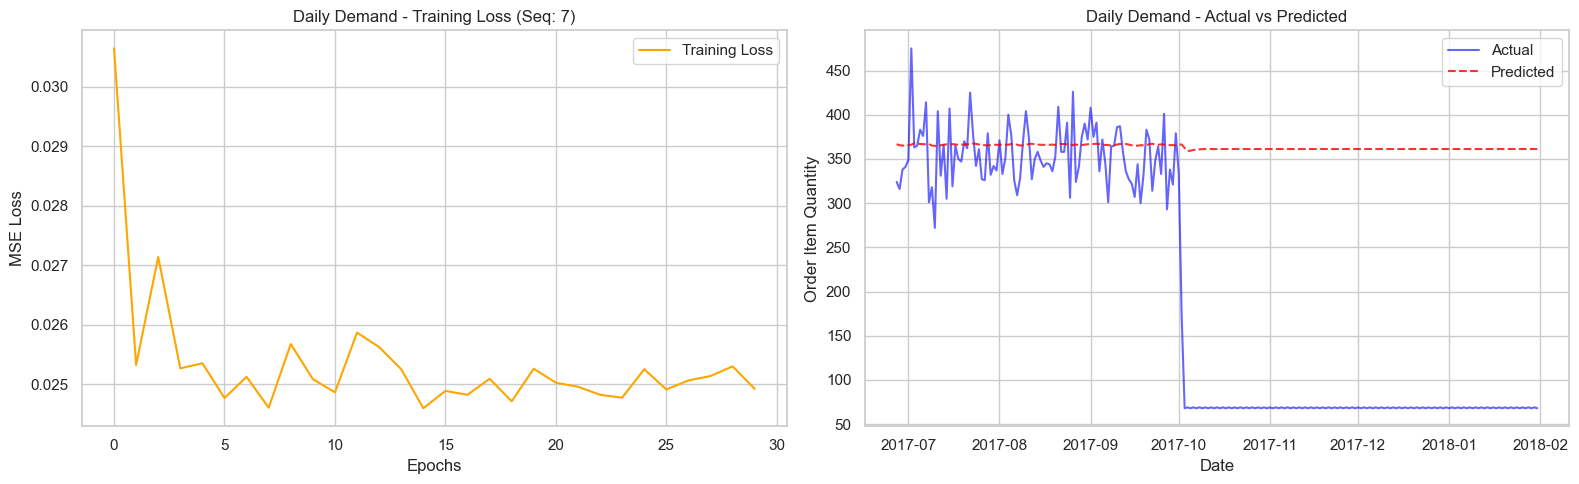

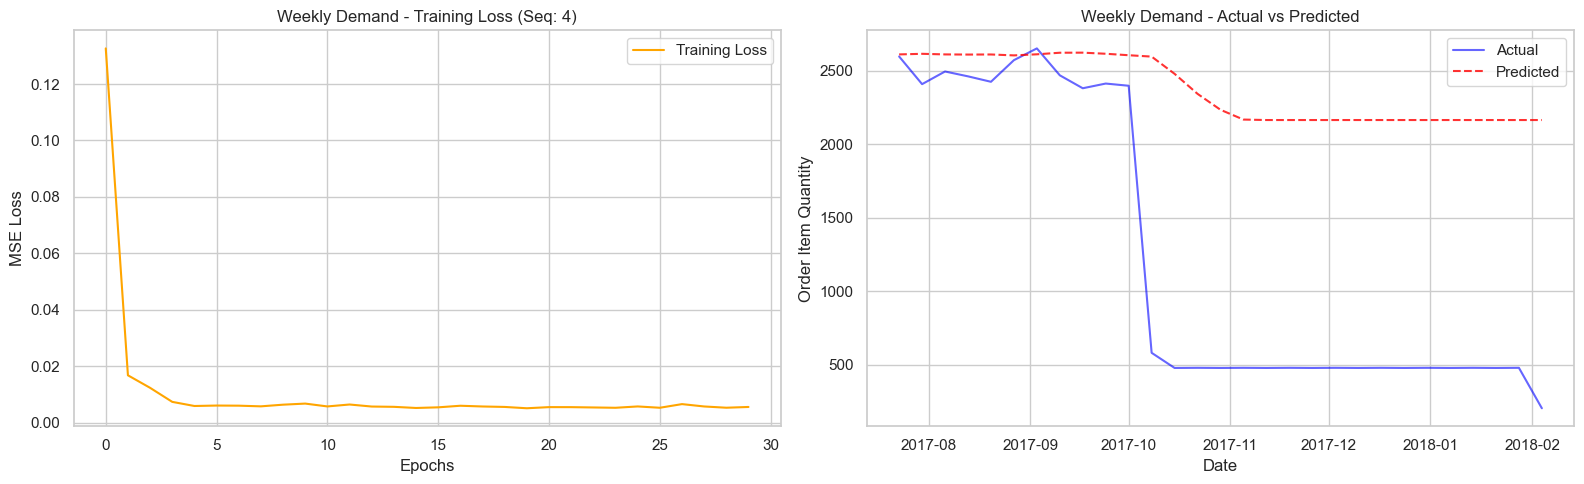

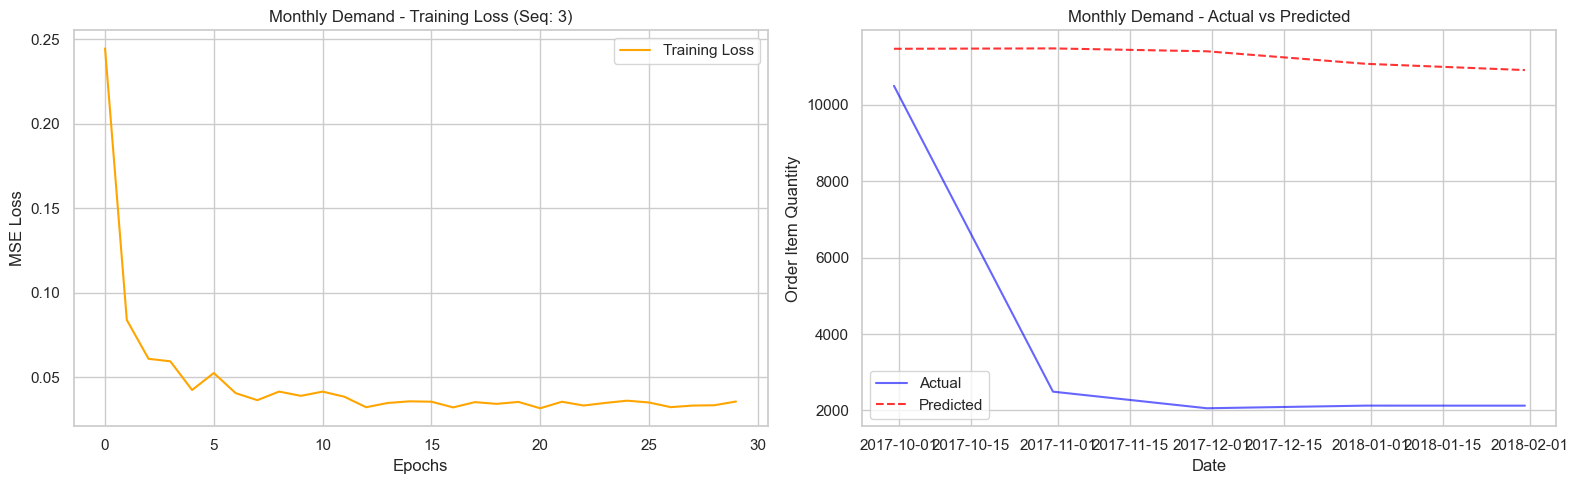

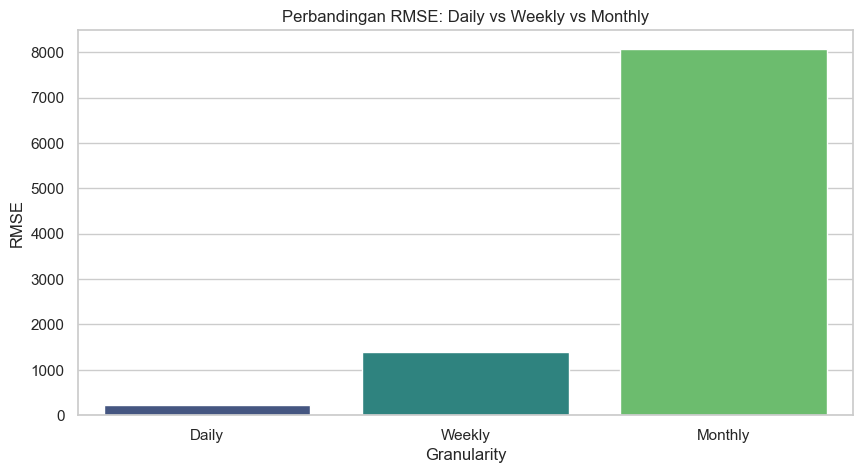

In [6]:
# Actual vs Predicted & Training Loss Plot
for name, best_info in zip(granularities.keys(), results_summary):
    preds = predictions_dict[name]
    losses = best_info['Train_Losses']
    seq = best_info['Best_Sequence']
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))
    
    # Loss Plot
    ax[0].plot(losses, color='orange', label='Training Loss')
    ax[0].set_title(f'{name} Demand - Training Loss (Seq: {seq})')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('MSE Loss')
    ax[0].legend()
    
    # Actual vs Predicted
    ax[1].plot(preds['Date'], preds['Actual'], label='Actual', color='blue', alpha=0.6)
    ax[1].plot(preds['Date'], preds['Predicted'], label='Predicted', color='red', alpha=0.8, linestyle='--')
    ax[1].set_title(f'{name} Demand - Actual vs Predicted')
    ax[1].set_xlabel('Date')
    ax[1].set_ylabel('Order Item Quantity')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()

# Comparison Chart: RMSE across granularities
plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x='Granularity', y='RMSE', palette='viridis')
plt.title('Perbandingan RMSE: Daily vs Weekly vs Monthly')
plt.ylabel('RMSE')
plt.show()

## Ekspor Hasil (Export Results)

Hasil prediksi, metrik, dan ringkasan model terbaik telah disimpan di dalam folder `data/predicted-1/`.

- `daily_predictions.csv`, `weekly_predictions.csv`, `monthly_predictions.csv`
- `daily_metrics.csv`, `weekly_metrics.csv`, `monthly_metrics.csv`
- `best_model_summary.csv`

In [7]:
print("Semua file telah berhasil diekspor ke folder 'data/predicted-1/'.")
import os
print("Isi folder predicted-1/:")
for f in os.listdir('data/predicted-1'):
    print(" -", f)

Semua file telah berhasil diekspor ke folder 'data/predicted-1/'.
Isi folder predicted-1/:
 - best_model_summary.csv
 - daily_metrics.csv
 - daily_predictions.csv
 - monthly_metrics.csv
 - monthly_predictions.csv
 - weekly_metrics.csv
 - weekly_predictions.csv


## Rekomendasi Akhir (Final Recommendation)

In [8]:
best_overall = df_results.loc[df_results['RMSE'].idxmin()]

print("### REKOMENDASI AKHIR ###\n")
print(f"Berdasarkan hasil evaluasi, model dengan performa terbaik (RMSE terendah) adalah:")
print(f"- Granularitas Terbaik : {best_overall['Granularity']}")
print(f"- Sequence Length      : {best_overall['Best_Sequence']}")
print(f"- RMSE                 : {best_overall['RMSE']:.2f}")

print(f"\nRekomendasi: Model GRU dengan granularitas {best_overall['Granularity']} (Sequence {best_overall['Best_Sequence']}) ")
print("harus digunakan sebagai input (batasan ketersediaan/permintaan) untuk tahap optimasi rantai pasok menggunakan Aquila Optimizer.")

### REKOMENDASI AKHIR ###

Berdasarkan hasil evaluasi, model dengan performa terbaik (RMSE terendah) adalah:
- Granularitas Terbaik : Daily
- Sequence Length      : 7
- RMSE                 : 219.21

Rekomendasi: Model GRU dengan granularitas Daily (Sequence 7) 
harus digunakan sebagai input (batasan ketersediaan/permintaan) untuk tahap optimasi rantai pasok menggunakan Aquila Optimizer.
